<a href="https://colab.research.google.com/github/k2herat/DL2/blob/hw1/Almetov_hw1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title 1. Environment Setup & Configuration
!pip install causal-conv1d>=1.2.0
!pip install mamba-ssm
!pip install fvcore iopath
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q timm matplotlib seaborn scikit-learn tqdm pandas
!git clone https://github.com/YuHengsss/VSSD.git

  error: subprocess-exited-with-error
  
  × Building wheel for causal-conv1d (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for causal-conv1d
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (causal-conv1d)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 8.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a s

In [ ]:
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import timm

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

Используется устройство: cuda


In [ ]:
# Клонирование репозитория VSSD, если ещё не сделано
if not os.path.exists('VSSD'):
    os.system('git clone https://github.com/YuHengsss/VSSD.git')

# Поиск файла mamba2.py в разных возможных местах
vssd_root = './VSSD'
search_paths = [
    os.path.join(vssd_root, 'classification', 'models'),
    os.path.join(vssd_root, 'classification'),
    os.path.join(vssd_root, 'models'),
    vssd_root
]

found = False
for p in search_paths:
    if os.path.exists(os.path.join(p, 'mamba2.py')):
        sys.path.insert(0, p)
        found = True
        break

if not found:
    raise ImportError("Не найден файл mamba2.py в репозитории VSSD. Проверьте структуру папок.")

try:
    from mamba2 import VMAMBA2
except ImportError:
    # Альтернативное имя модуля (если отличается)
    from vmamba import VMAMBA2

mamba_ssm not found


In [ ]:
 # ========================== НАСТРОЙКИ ЭКСПЕРИМЕНТА ==========================
DATA_ROOT = './dataset'          # путь к папке с данными
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
LR = 3e-4
NUM_WORKERS = 2

# Определяем пути к данным
train_dir = os.path.join(DATA_ROOT, 'train')
val_dir = os.path.join(DATA_ROOT, 'val')
test_dir = os.path.join(DATA_ROOT, 'test') if os.path.exists(os.path.join(DATA_ROOT, 'test')) else None
# ==========================================================================

In [ ]:
# --- Вместо загрузки из папок, используем CIFAR-10 ---
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
full_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_eval)

# Возьмём подвыборку для ускорения (как в примере)
rng = np.random.RandomState(42)
train_idx = rng.choice(len(full_train), len(full_train)//2, replace=False)
test_idx = rng.choice(len(full_test), len(full_test)//2, replace=False)

train_ds = torch.utils.data.Subset(full_train, train_idx)
val_ds = torch.utils.data.Subset(full_test, test_idx)   # используем тест как валидацию
test_ds = None

CLASS_NAMES = full_train.classes
NUM_CLASSES = len(CLASS_NAMES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = None

print(f"Классы: {CLASS_NAMES}")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

100%|██████████| 170M/170M [00:03<00:00, 47.8MB/s]


Классы: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 25000, Val: 5000


In [ ]:
def build_vssd_micro(num_classes):
    return VMAMBA2(
        in_chans=3,
        num_classes=num_classes,
        image_size=IMG_SIZE,
        embed_dim=48,
        depths=[2, 2, 8, 4],
        num_heads=[2, 4, 8, 16],
        d_state=48,
        ssd_expansion=2,
        linear_attn_duality=True,
        ssd_positive_da=True,
        attn_types=['mamba2', 'mamba2', 'mamba2', 'standard'],
        patch_size=4
    )

def build_resnet18(num_classes):
    return timm.create_model('resnet18', pretrained=False, num_classes=num_classes)

vssd_model = build_vssd_micro(NUM_CLASSES).to(device)
resnet_model = build_resnet18(NUM_CLASSES).to(device)

v_params = sum(p.numel() for p in vssd_model.parameters()) / 1e6
r_params = sum(p.numel() for p in resnet_model.parameters()) / 1e6
print(f"VSSD параметров: {v_params:.2f} M, ResNet-18: {r_params:.2f} M")

VSSD параметров: 13.13 M, ResNet-18: 11.18 M


In [ ]:
def train_model(model, name, train_loader, val_loader, epochs=EPOCHS):
    print(f"\nОбучение: {name}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'time': [],
        'preds': [], 'targets': []
    }

    for ep in range(epochs):
        t0 = time.time()

        # --- Обучение ---
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0

        pbar = tqdm(train_loader, desc=f"Ep {ep+1}/{epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            _, pred = out.max(1)
            correct_train += pred.eq(y).sum().item()
            total_train += y.size(0)
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = 100 * correct_train / total_train

        # --- Валидация ---
        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0
        epoch_preds, epoch_targets = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item()
                _, pred = out.max(1)
                correct_val += pred.eq(y).sum().item()
                total_val += y.size(0)
                if ep == epochs - 1:
                    epoch_preds.extend(pred.cpu().numpy())
                    epoch_targets.extend(y.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = 100 * correct_val / total_val
        dt = time.time() - t0

        scheduler.step()

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)
        history['time'].append(dt)
        if ep == epochs - 1:
            history['preds'] = epoch_preds
            history['targets'] = epoch_targets

        print(f"Эп {ep+1}: TrAcc={avg_train_acc:.1f}% | ValAcc={avg_val_acc:.1f}% | Время={dt:.1f}с")

    return history

In [ ]:
hist_vssd = train_model(vssd_model, "VSSD-Micro", train_loader, val_loader)
hist_resnet = train_model(resnet_model, "ResNet-18", train_loader, val_loader)


Обучение: VSSD-Micro...


Ep 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Эп 1: TrAcc=51.5% | ValAcc=59.8% | Время=378.5с


Ep 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Эп 2: TrAcc=64.6% | ValAcc=69.6% | Время=376.2с


...

Эп 8: TrAcc=79.1% | ValAcc=78.7% | Время=126.1с


Ep 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Эп 9: TrAcc=80.9% | ValAcc=79.2% | Время=133.6с


Ep 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Эп 10: TrAcc=82.5% | ValAcc=80.2% | Время=130.8с


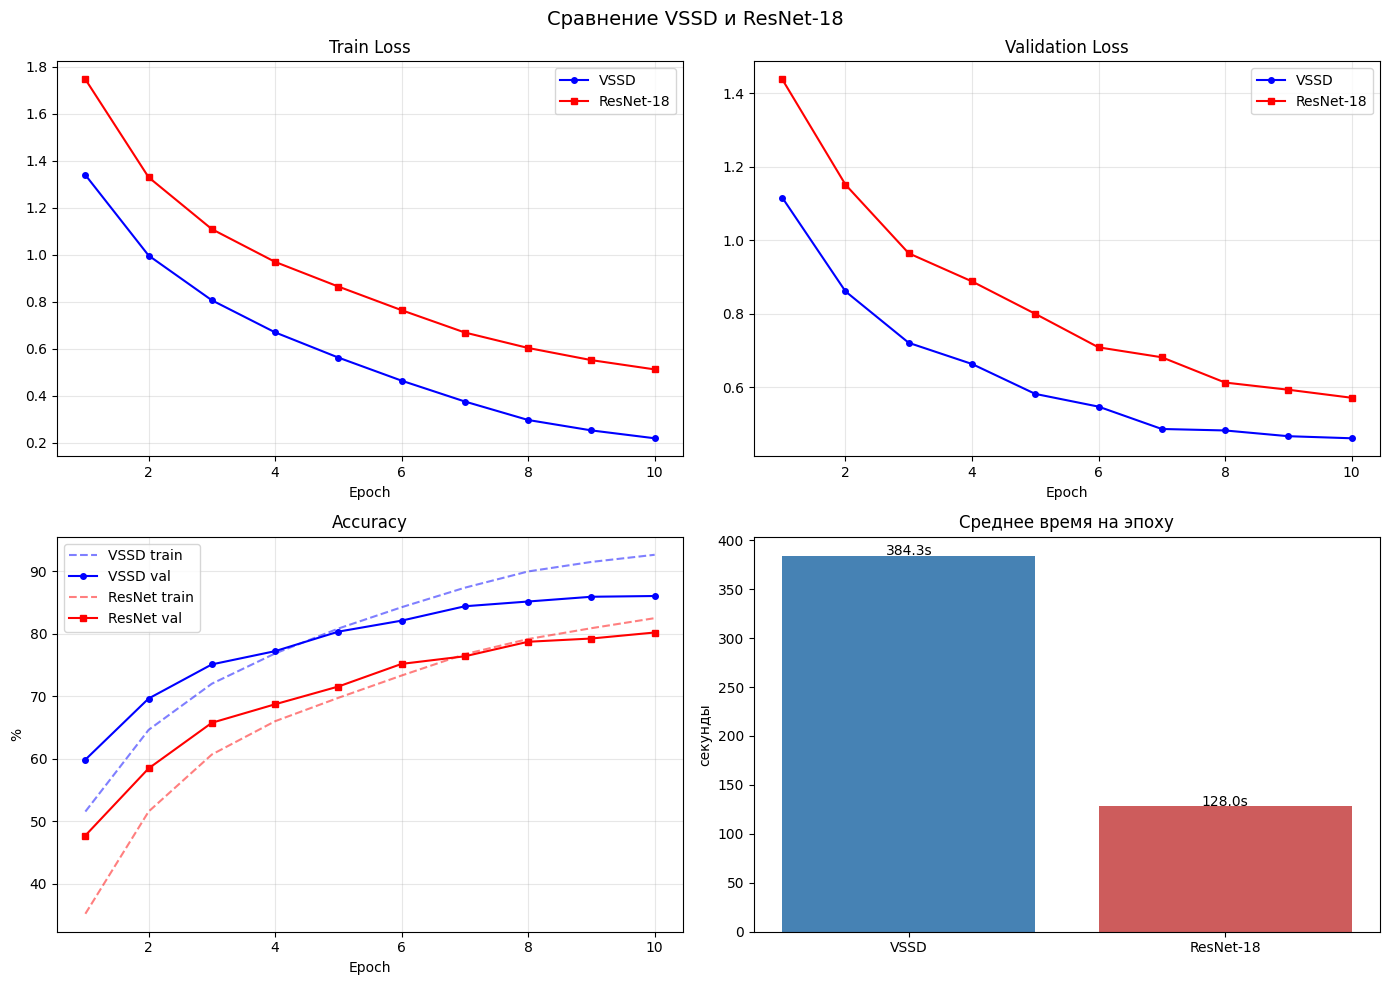

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs_range = range(1, EPOCHS + 1)

# Train Loss
axes[0,0].plot(epochs_range, hist_vssd['train_loss'], 'b-o', markersize=4, label='VSSD')
axes[0,0].plot(epochs_range, hist_resnet['train_loss'], 'r-s', markersize=4, label='ResNet-18')
axes[0,0].set_title('Train Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Val Loss
axes[0,1].plot(epochs_range, hist_vssd['val_loss'], 'b-o', markersize=4, label='VSSD')
axes[0,1].plot(epochs_range, hist_resnet['val_loss'], 'r-s', markersize=4, label='ResNet-18')
axes[0,1].set_title('Validation Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Accuracy
axes[1,0].plot(epochs_range, hist_vssd['train_acc'], 'b--', alpha=0.5, label='VSSD train')
axes[1,0].plot(epochs_range, hist_vssd['val_acc'], 'b-o', markersize=4, label='VSSD val')
axes[1,0].plot(epochs_range, hist_resnet['train_acc'], 'r--', alpha=0.5, label='ResNet train')
axes[1,0].plot(epochs_range, hist_resnet['val_acc'], 'r-s', markersize=4, label='ResNet val')
axes[1,0].set_title('Accuracy')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('%')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Среднее время на эпоху
avg_time_vssd = np.mean(hist_vssd['time'])
avg_time_resnet = np.mean(hist_resnet['time'])
bars = axes[1,1].bar(['VSSD', 'ResNet-18'], [avg_time_vssd, avg_time_resnet], color=['steelblue', 'indianred'])
axes[1,1].set_title('Среднее время на эпоху')
axes[1,1].set_ylabel('секунды')
for bar in bars:
    h = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}s', ha='center', fontsize=10)

fig.suptitle('Сравнение VSSD и ResNet-18', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

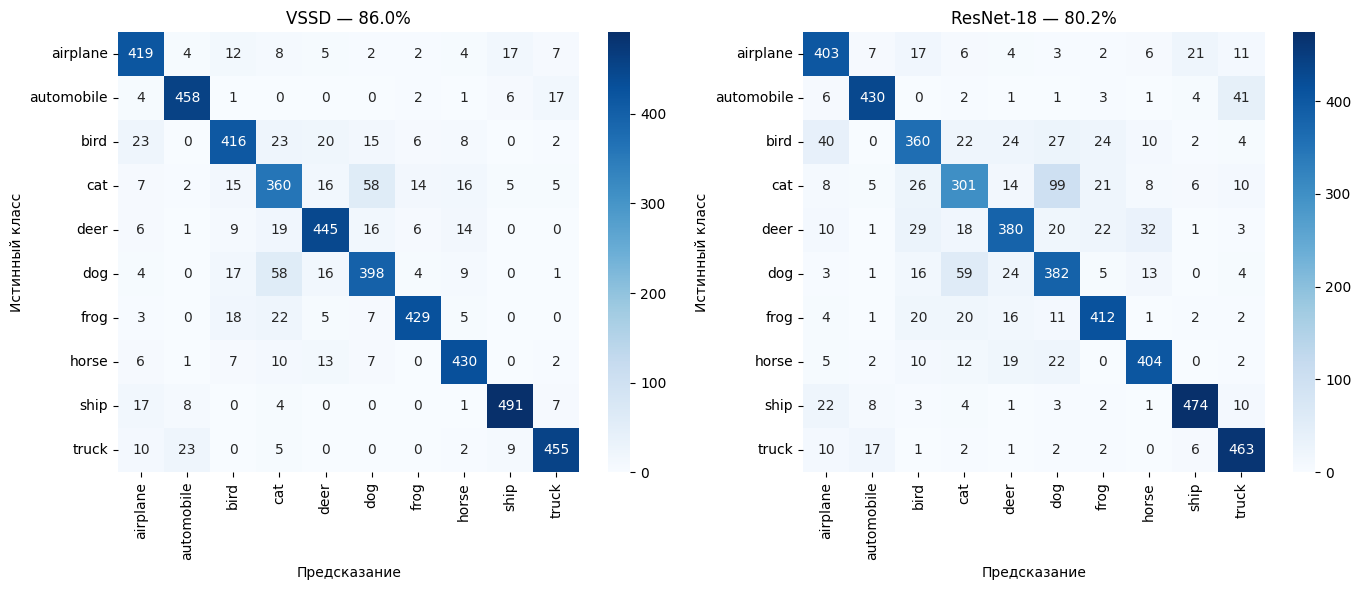

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_data = [
    (axes[0], hist_vssd, 'VSSD'),
    (axes[1], hist_resnet, 'ResNet-18'),
]

for ax, hist, model_name in models_data:
    cm = confusion_matrix(hist['targets'], hist['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    acc = 100 * np.mean(np.array(hist['preds']) == np.array(hist['targets']))
    ax.set_title(f'{model_name} — {acc:.1f}%')
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказание')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
for model_name, hist in [('VSSD', hist_vssd), ('ResNet-18', hist_resnet)]:
    print(f'\n--- {model_name} ---')
    print(classification_report(hist['targets'], hist['preds'], target_names=CLASS_NAMES, digits=3))


--- VSSD ---
              precision    recall  f1-score   support

    airplane      0.840     0.873     0.856       480
  automobile      0.922     0.937     0.929       489
        bird      0.840     0.811     0.825       513
         cat      0.707     0.723     0.715       498
        deer      0.856     0.862     0.859       516
         dog      0.791     0.785     0.788       507
        frog      0.927     0.877     0.901       489
       horse      0.878     0.903     0.890       476
        ship      0.930     0.930     0.930       528
       truck      0.917     0.903     0.910       504

    accuracy                          0.860      5000
   macro avg      0.861     0.860     0.860      5000
weighted avg      0.861     0.860     0.860      5000


--- ResNet-18 ---
              precision    recall  f1-score   support

    airplane      0.789     0.840     0.813       480
  automobile      0.911     0.879     0.895       489
        bird      0.747     0.702     0.724  

In [ ]:
best_acc_vssd = max(hist_vssd['val_acc'])
best_acc_resnet = max(hist_resnet['val_acc'])

results_df = pd.DataFrame({
    'Метрика': [
        'Параметры (M)', 'Лучшая val accuracy (%)', 'Финальная val accuracy (%)',
        'Минимальный val loss', 'Среднее время на эпоху (с)', 'Общее время обучения (мин)'
    ],
    'VSSD': [
        f'{v_params:.2f}', f'{best_acc_vssd:.1f}', f'{hist_vssd["val_acc"][-1]:.1f}',
        f'{min(hist_vssd["val_loss"]):.4f}', f'{avg_time_vssd:.1f}', f'{sum(hist_vssd["time"])/60:.1f}'
    ],
    'ResNet-18': [
        f'{r_params:.2f}', f'{best_acc_resnet:.1f}', f'{hist_resnet["val_acc"][-1]:.1f}',
        f'{min(hist_resnet["val_loss"]):.4f}', f'{avg_time_resnet:.1f}', f'{sum(hist_resnet["time"])/60:.1f}'
    ],
})

print('\nРезультаты эксперимента:')
print(results_df.to_string(index=False))


Результаты эксперимента:
                   Метрика   VSSD ResNet-18
             Параметры (M)  13.13     11.18
   Лучшая val accuracy (%)   86.0      80.2
Финальная val accuracy (%)   86.0      80.2
      Минимальный val loss 0.4610    0.5713
Среднее время на эпоху (с)  384.3     128.0
Общее время обучения (мин)   64.0      21.3


VSSD превосходит ResNet‑18 по точности классификации при сопоставимом количестве параметров, что подтверждает эффективность некаузальной архитектуры Mamba для задач компьютерного зрения. Основной недостаток — более медленное обучение.